In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.special import rel_entr  # KL divergence helper

# ---------- 3-Agent IPD ENVIRONMENT -----------
class IPDEnvironment3A:
    """
    3-Agent IPD Environment:
    - States are integers {0 to 7}, representing:
      0: CCC, 1: CCD, 2: CDC, 3: CDD, 4: DCC, 5: DCD, 6: DDC, 7: DDD
    """
    def __init__(self):
        self.state = None
        self.reset()

    def reset(self):
        self.state = np.random.choice(8)
        return self.state

    def step(self, a1, a2, a3):
        # Convert 3 binary actions to a unique integer (0 to 7)
        self.state = 4 * a1 + 2 * a2 + 1 * a3
        return self.state

# ✅ Quick test
env = IPDEnvironment3A()
print("Initial state:", env.state)
print("Next state if Agents = (0, 1, 1):", env.step(0, 1, 1))  # should return state 3 (CDD)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Initial state: 3
Next state if Agents = (0, 1, 1): 3


In [2]:
# === Hyperparameter Configuration ===

default_eta1 = 0.6
default_eta2 = 0.6
default_eta3 = 0.6

default_alpha1 = 6
default_alpha2 = 6
default_alpha3 = 6

default_gamma = 0.0

default_N = 500
default_runs = 15

C1 = np.array([3,   0.5, 0.5, 0.5, 4,   2.5, 2.5, 1])
C2 = np.array([3,   0.5, 4,   2.5, 0.5, 0.5, 2.5, 1])
C3 = np.array([3,   4,   0.5, 2.5, 0.5, 2.5, 0.5, 1])

In [3]:
class ActiveInferenceAgent:
    """
    Active Inference Agent for 3-Agent IPD:
    - Learns an 8×8×2 transition model B via Dirichlet counts (pB).
    - Uses a perfect identity observation model A (8×8).
    - Chooses actions by minimizing expected free energy:
      EFE(a) = Risk - gamma * Epistemic Value
    """
    def __init__(self, name, C, alpha=4.0, eta=0.3, gamma=1.0):
        self.name = name
        self.alpha = alpha
        self.eta = eta
        self.gamma = gamma

        self.C = C
        self.Pref = np.exp(self.C) / (np.sum(np.exp(self.C)) + 1e-15)

        # B and pB must now be 8×8×2
        self.pB = np.ones((8, 8, 2))  # Dirichlet prior counts
        self.B  = np.zeros((8, 8, 2)) # Normalized transition model
        self._normalize_B()

        # Observation model A: identity (8×8)
        self.A = np.eye(8)

        # Prior belief over hidden states
        self.D = np.ones(8) / 8
        self.qs = self.D.copy()

    def _normalize_B(self):
        for old_s in range(8):
            for a in range(2):
                col_sum = self.pB[:, old_s, a].sum()
                self.B[:, old_s, a] = self.pB[:, old_s, a] / (col_sum + 1e-15)

    def observe_and_infer_state(self, obs_state):
        likelihood = self.A[obs_state, :]
        posterior = likelihood * self.D
        self.qs = posterior / (np.sum(posterior) + 1e-15)

    def compute_negEFE_for_action(self, a):
        eps = 1e-8
        pred_states = np.zeros(8)
        for s in range(8):
            pred_states += self.qs[s] * self.B[:, s, a]

        # Risk = KL divergence between predicted and preferred states
        risk = np.sum(pred_states * (np.log(pred_states + eps) - np.log(self.Pref + eps)))

        # Epistemic value = entropy of predicted observations
        pred_obs = self.A @ pred_states
        entropy = -np.sum(pred_obs * np.log(pred_obs + eps))

        return risk - self.gamma * entropy

    def select_action(self):
        Gc = self.compute_negEFE_for_action(0)
        Gd = self.compute_negEFE_for_action(1)
        Xc = -self.alpha * Gc
        Xd = -self.alpha * Gd
        pC = np.exp(Xc) / (np.exp(Xc) + np.exp(Xd) + 1e-15)
        return 0 if np.random.rand() < pC else 1

    def update_transition_model(self, old_state, action, new_state):
        self.pB[:, old_state, action] *= (1.0 - self.eta)
        self.pB[new_state, old_state, action] += self.eta
        self._normalize_B()

    def compute_efes(self):
        return self.compute_negEFE_for_action(0), self.compute_negEFE_for_action(1)


In [4]:
np.random.seed(42)

# Preferences for all 3 agents (length-8 arrays)
# Agent 1 payoff
C1 = np.array([3,   0.5, 0.5, 0.5, 4,   2.5, 2.5, 1])
C2 = np.array([3,   0.5, 4,   2.5, 0.5, 0.5, 2.5, 1])
C3 = np.array([3,   4,   0.5, 2.5, 0.5, 2.5, 0.5, 1])

# Instantiate 3-agent environment and agents
env    = IPDEnvironment3A()
agent1 = ActiveInferenceAgent("A1", C1, alpha=default_alpha1, eta=default_eta1, gamma=default_gamma)
agent2 = ActiveInferenceAgent("A2", C2, alpha=default_alpha2, eta=default_eta2, gamma=default_gamma)
agent3 = ActiveInferenceAgent("A3", C3, alpha=default_alpha3, eta=default_eta3, gamma=default_gamma)

# Initialize state
old_state = env.state
N = default_N  # Number of rounds

# Logging containers
states_history = []
a1_history, a2_history, a3_history = [], [], []

efe1_C, efe1_D = [], []
efe2_C, efe2_D = [], []
efe3_C, efe3_D = [], []

B_snap_1, B_snap_2, B_snap_3 = [], [], []

# ——— SIMULATION ———
for t in range(N):
    # 1) Observation and inference
    agent1.observe_and_infer_state(env.state)
    agent2.observe_and_infer_state(env.state)
    agent3.observe_and_infer_state(env.state)

    # 2) Compute and log EFEs
    Gc1, Gd1 = agent1.compute_efes()
    Gc2, Gd2 = agent2.compute_efes()
    Gc3, Gd3 = agent3.compute_efes()
    efe1_C.append(Gc1); efe1_D.append(Gd1)
    efe2_C.append(Gc2); efe2_D.append(Gd2)
    efe3_C.append(Gc3); efe3_D.append(Gd3)

    # 3) Action selection
    if t == 0:
        a1, a2, a3 = np.random.choice([0, 1], 3)
    else:
        a1 = agent1.select_action()
        a2 = agent2.select_action()
        a3 = agent3.select_action()

    # 4) Environment transition
    s_new = env.step(a1, a2, a3)

    # 5) Update transition models
    agent1.update_transition_model(old_state, a1, s_new)
    agent2.update_transition_model(old_state, a2, s_new)
    agent3.update_transition_model(old_state, a3, s_new)

    # 6) Log B-matrix snapshots
    B_snap_1.append(agent1.B.copy())
    B_snap_2.append(agent2.B.copy())
    B_snap_3.append(agent3.B.copy())

    # 7) Log states and actions
    states_history.append(s_new)
    a1_history.append(a1)
    a2_history.append(a2)
    a3_history.append(a3)

    old_state = s_new

print("Simulation complete. Final state:", states_history[-1])


Simulation complete. Final state: 7


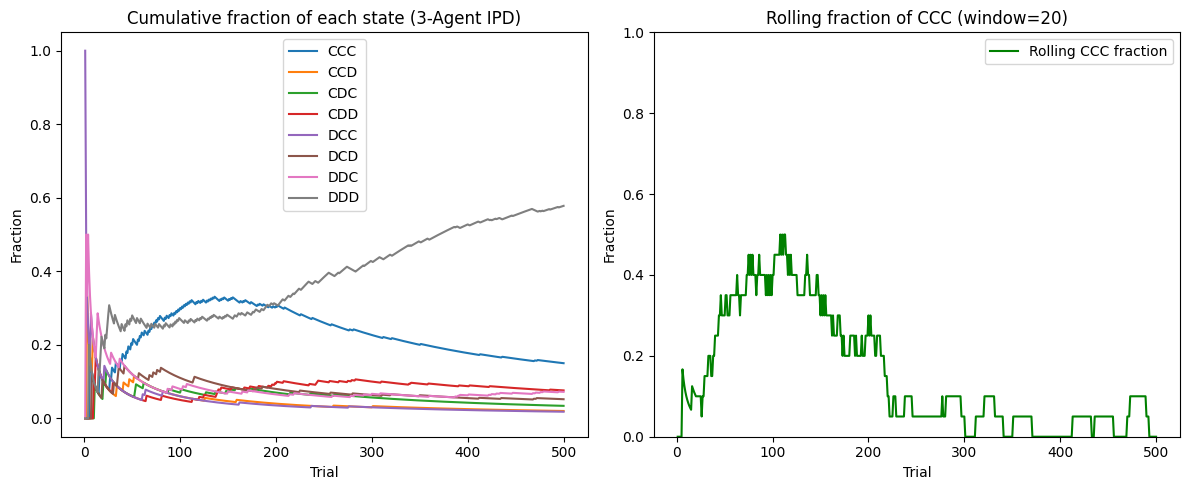


=== Final fraction of states over entire run ===
CCC: 15.00%
CCD: 2.00%
CDC: 3.40%
CDD: 7.60%
DCC: 1.80%
DCD: 5.20%
DDC: 7.20%
DDD: 57.80%


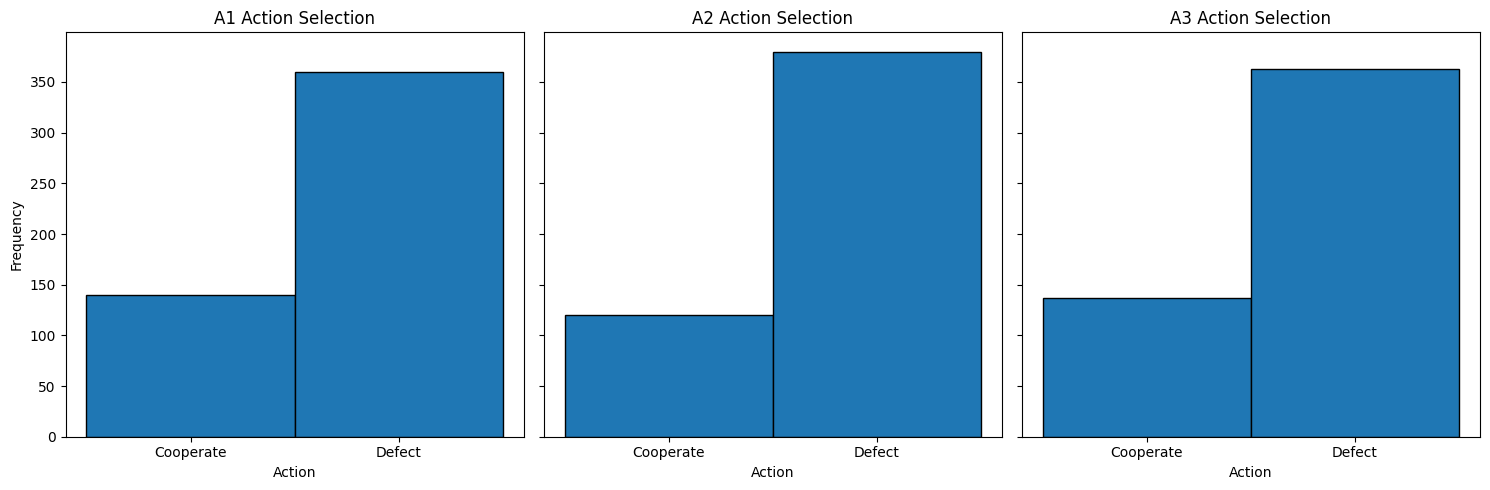

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Plotting: State Frequencies and Cooperation Dynamics ---
states_history = np.array(states_history)

# (1) Cumulative frequency of each state over time (8 states)
state_counts = np.zeros((8, N), dtype=float)
for t in range(N):
    s = states_history[t]
    state_counts[s, t] = 1.0
cum_counts = np.cumsum(state_counts, axis=1)

# (2) Rolling fraction of 'CCC' (state 0)
window_size = 20
rolling_frac_ccc = np.zeros(N)
for t in range(N):
    left = max(0, t - window_size + 1)
    segment = states_history[left:t + 1]
    ccc_count = np.sum(segment == 0)
    rolling_frac_ccc[t] = ccc_count / len(segment)

# --- Subplots: cumulative + rolling plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
t_range = np.arange(1, N + 1)

# Plot 1: Cumulative fraction of each state
state_labels = ['CCC', 'CCD', 'CDC', 'CDD', 'DCC', 'DCD', 'DDC', 'DDD']
for i, lbl in enumerate(state_labels):
    frac_i = cum_counts[i, :] / t_range
    axes[0].plot(t_range, frac_i, label=lbl)
axes[0].set_title("Cumulative fraction of each state (3-Agent IPD)")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Fraction")
axes[0].legend()

# Plot 2: Rolling CCC fraction
axes[1].plot(t_range, rolling_frac_ccc, color='green', label="Rolling CCC fraction")
axes[1].set_title("Rolling fraction of CCC (window=20)")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Fraction")
axes[1].set_ylim([0, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Final State Summary ---
final_counts = cum_counts[:, -1]
final_fracs = final_counts / N
print("\n=== Final fraction of states over entire run ===")
for i, lbl in enumerate(state_labels):
    print(f"{lbl}: {final_fracs[i]*100:.2f}%")

# --- Action Histograms for All Agents ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
action_labels = ['Cooperate', 'Defect']
bins = np.arange(len(action_labels) + 1) - 0.5

for idx, (hist, name, ax) in enumerate(zip(
    [a1_history, a2_history, a3_history],
    [agent1.name, agent2.name, agent3.name],
    axes
)):
    ax.hist(hist, bins=bins, edgecolor='black')
    ax.set_xticks(range(len(action_labels)))
    ax.set_xticklabels(action_labels)
    ax.set_title(f'{name} Action Selection')
    ax.set_xlabel('Action')
    if idx == 0:
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


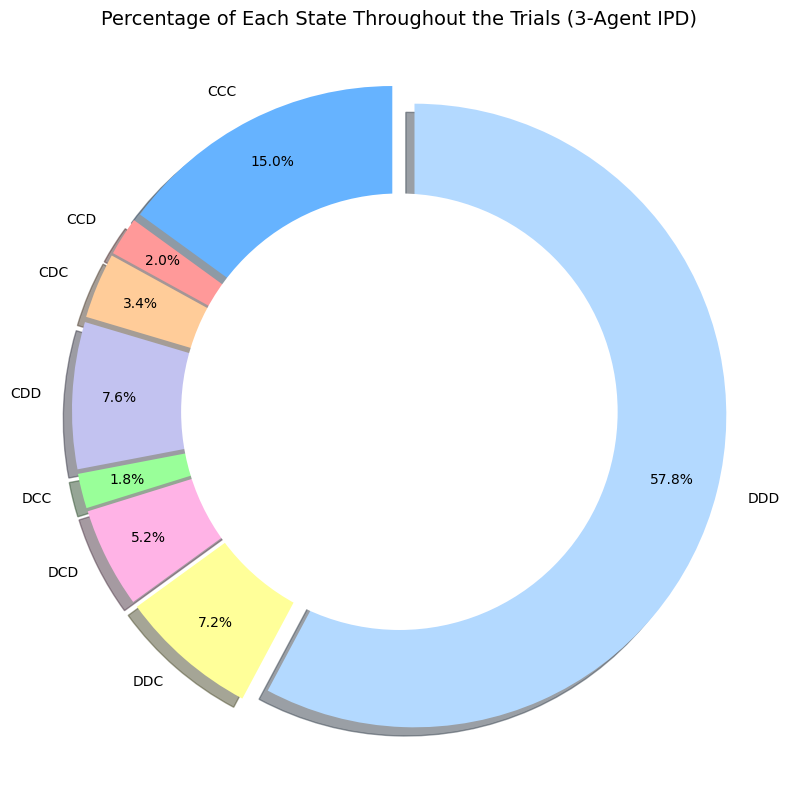

In [6]:
# --- Pie Chart of Final State Distribution (3 Agents) ---
fig, ax = plt.subplots(figsize=(8, 8))

# Count how many times each state occurred
state_counts = np.bincount(states_history, minlength=8)

# Define 8 state labels
state_labels = [
    'CCC', 'CCD', 'CDC', 'CDD',
    'DCC', 'DCD', 'DDC', 'DDD'
]

# Define 8 visually distinct colors
colors = ['#66b3ff', '#ff9999', '#ffcc99', '#c2c2f0',
          '#99ff99', '#ffb3e6', '#ffff99', '#b3d9ff']

explode = [0.05] * 8  # Slight separation of all slices

# Plot pie chart
wedges, texts, autotexts = ax.pie(
    state_counts,
    labels=state_labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    colors=colors,
    pctdistance=0.85,
    shadow=True,
    textprops=dict(color='black', fontsize=10)
)

# Add inner circle (donut style)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.axis('equal')
ax.set_title('Percentage of Each State Throughout the Trials (3-Agent IPD)', fontsize=14)

plt.tight_layout()
plt.show()


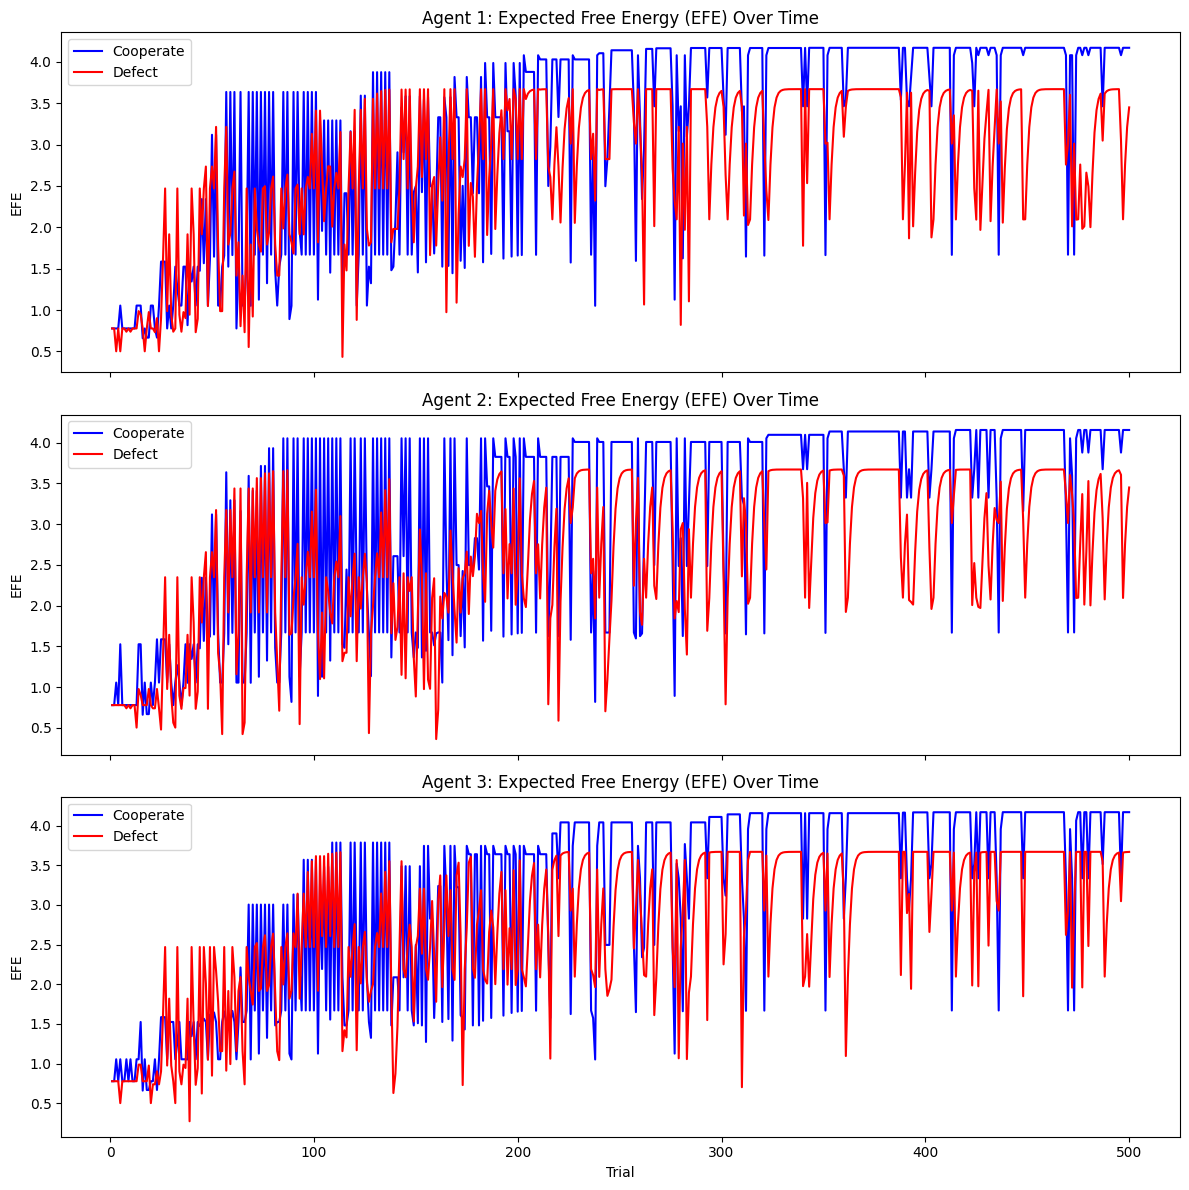

In [7]:
# --- Plot: EFE for All Agents Over Time ---
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

t_range = np.arange(1, N + 1)

# Agent 1
axes[0].plot(t_range, efe1_C, label='Cooperate', color='blue')
axes[0].plot(t_range, efe1_D, label='Defect', color='red')
axes[0].set_title('Agent 1: Expected Free Energy (EFE) Over Time')
axes[0].set_ylabel('EFE')
axes[0].legend()

# Agent 2
axes[1].plot(t_range, efe2_C, label='Cooperate', color='blue')
axes[1].plot(t_range, efe2_D, label='Defect', color='red')
axes[1].set_title('Agent 2: Expected Free Energy (EFE) Over Time')
axes[1].set_ylabel('EFE')
axes[1].legend()

# Agent 3
axes[2].plot(t_range, efe3_C, label='Cooperate', color='blue')
axes[2].plot(t_range, efe3_D, label='Defect', color='red')
axes[2].set_title('Agent 3: Expected Free Energy (EFE) Over Time')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('EFE')
axes[2].legend()

plt.tight_layout()
plt.show()


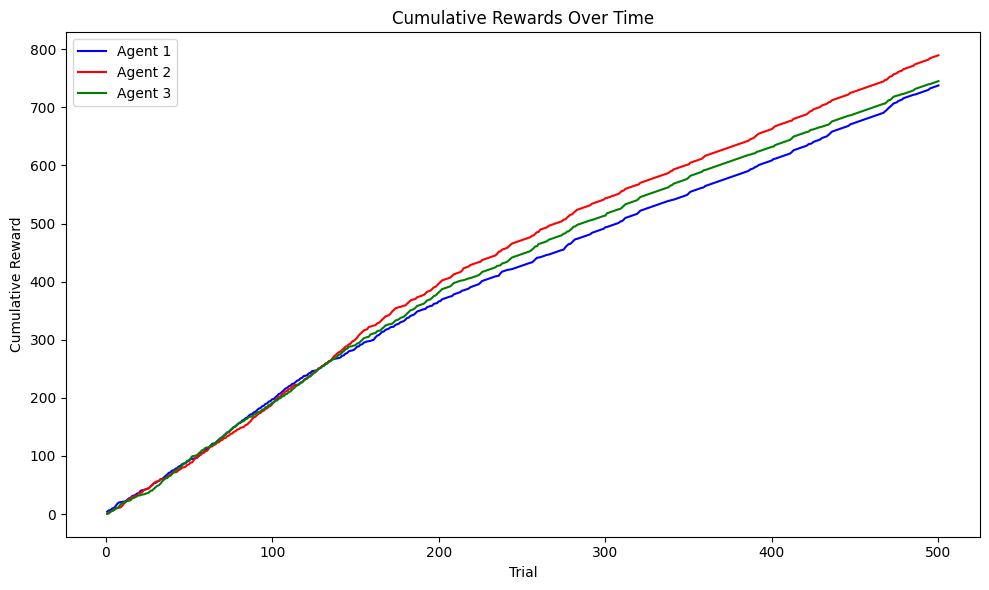

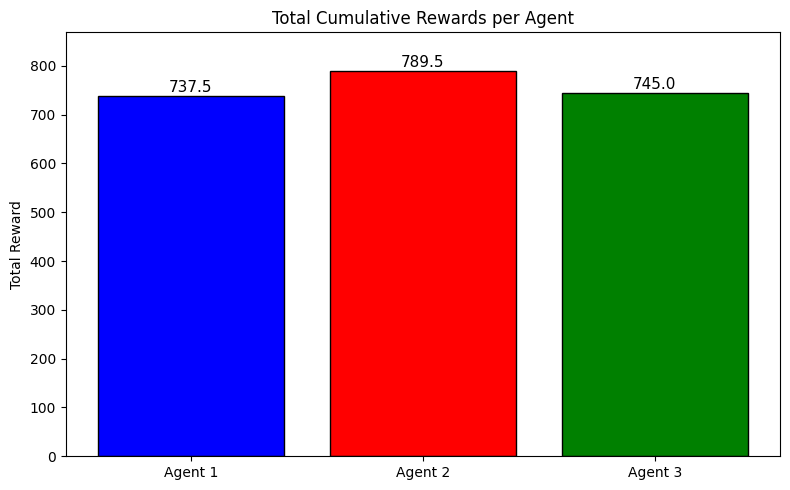

In [8]:
# --- Cumulative Rewards Over Time ---
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate cumulative reward per agent over time
cumulative_rewards_agent1 = np.cumsum([C1[state] for state in states_history])
cumulative_rewards_agent2 = np.cumsum([C2[state] for state in states_history])
cumulative_rewards_agent3 = np.cumsum([C3[state] for state in states_history])

# Plot over trials
ax.plot(t_range, cumulative_rewards_agent1, label='Agent 1', color='blue')
ax.plot(t_range, cumulative_rewards_agent2, label='Agent 2', color='red')
ax.plot(t_range, cumulative_rewards_agent3, label='Agent 3', color='green')

ax.set_title('Cumulative Rewards Over Time')
ax.set_xlabel('Trial')
ax.set_ylabel('Cumulative Reward')
ax.legend()

plt.tight_layout()
plt.show()

# --- Final Reward Comparison ---
final_rewards_3agents = [
    np.sum([C1[s] for s in states_history]),
    np.sum([C2[s] for s in states_history]),
    np.sum([C3[s] for s in states_history])
]

fig, ax = plt.subplots(figsize=(8, 5))
agent_labels = ['Agent 1', 'Agent 2', 'Agent 3']
colors_3 = ['blue', 'red', 'green']

bars = ax.bar(agent_labels, final_rewards_3agents, color=colors_3, edgecolor='black')

# Annotate bars with total values
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{height:.1f}', ha='center', va='bottom', fontsize=11)

ax.set_title('Total Cumulative Rewards per Agent')
ax.set_ylabel('Total Reward')
ax.set_ylim(0, max(final_rewards_3agents) * 1.1)

plt.tight_layout()
plt.show()


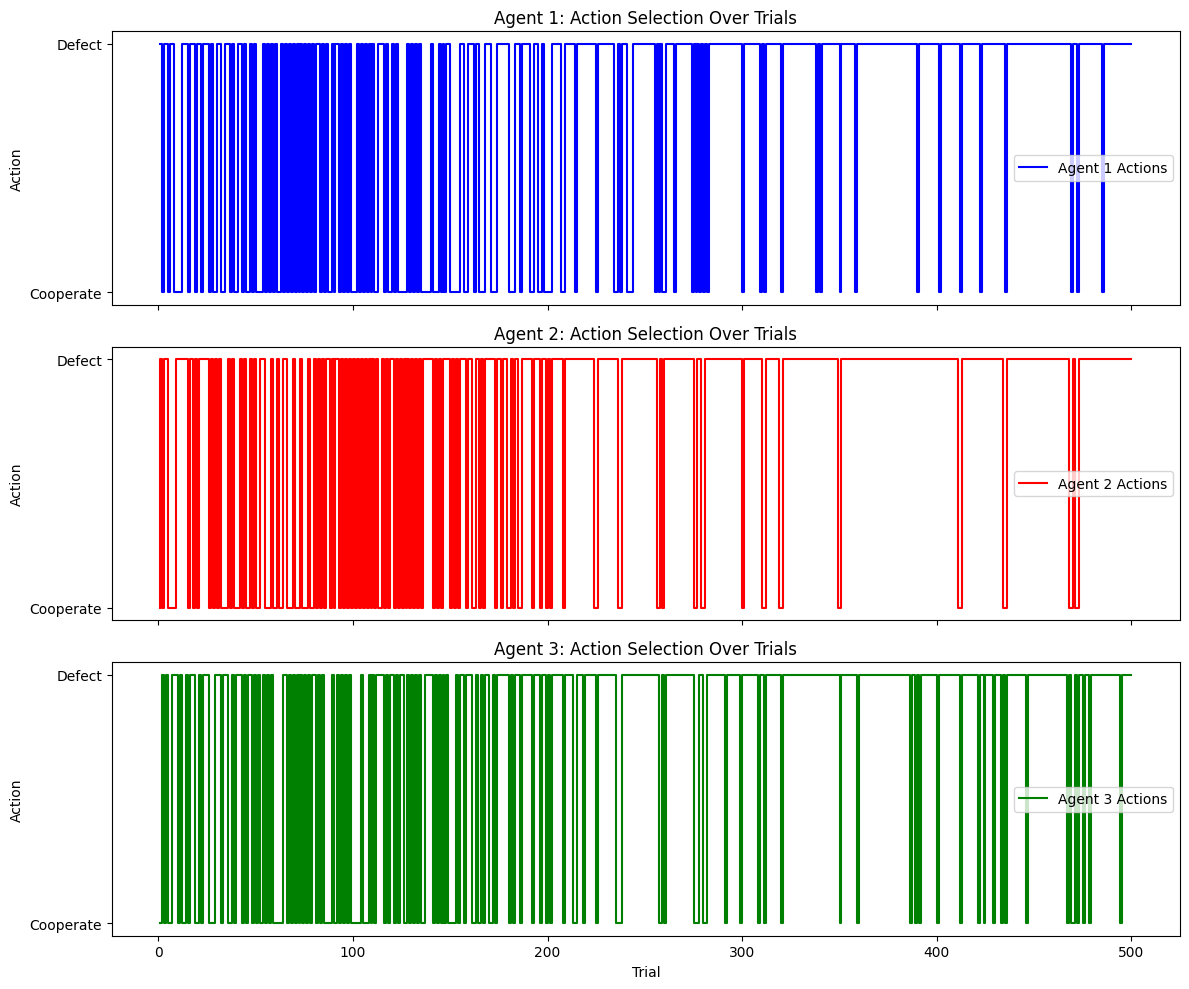

In [9]:
# --- Agents' Action Selections Over Time ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
t_range = np.arange(1, N + 1)

# Agent 1
axes[0].plot(t_range, a1_history, drawstyle='steps-pre', label='Agent 1 Actions', color='blue')
axes[0].set_title('Agent 1: Action Selection Over Trials')
axes[0].set_ylabel('Action')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Cooperate', 'Defect'])
axes[0].legend()

# Agent 2
axes[1].plot(t_range, a2_history, drawstyle='steps-pre', label='Agent 2 Actions', color='red')
axes[1].set_title('Agent 2: Action Selection Over Trials')
axes[1].set_ylabel('Action')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Cooperate', 'Defect'])
axes[1].legend()

# Agent 3
axes[2].plot(t_range, a3_history, drawstyle='steps-pre', label='Agent 3 Actions', color='green')
axes[2].set_title('Agent 3: Action Selection Over Trials')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Action')
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Cooperate', 'Defect'])
axes[2].legend()

plt.tight_layout()
plt.show()


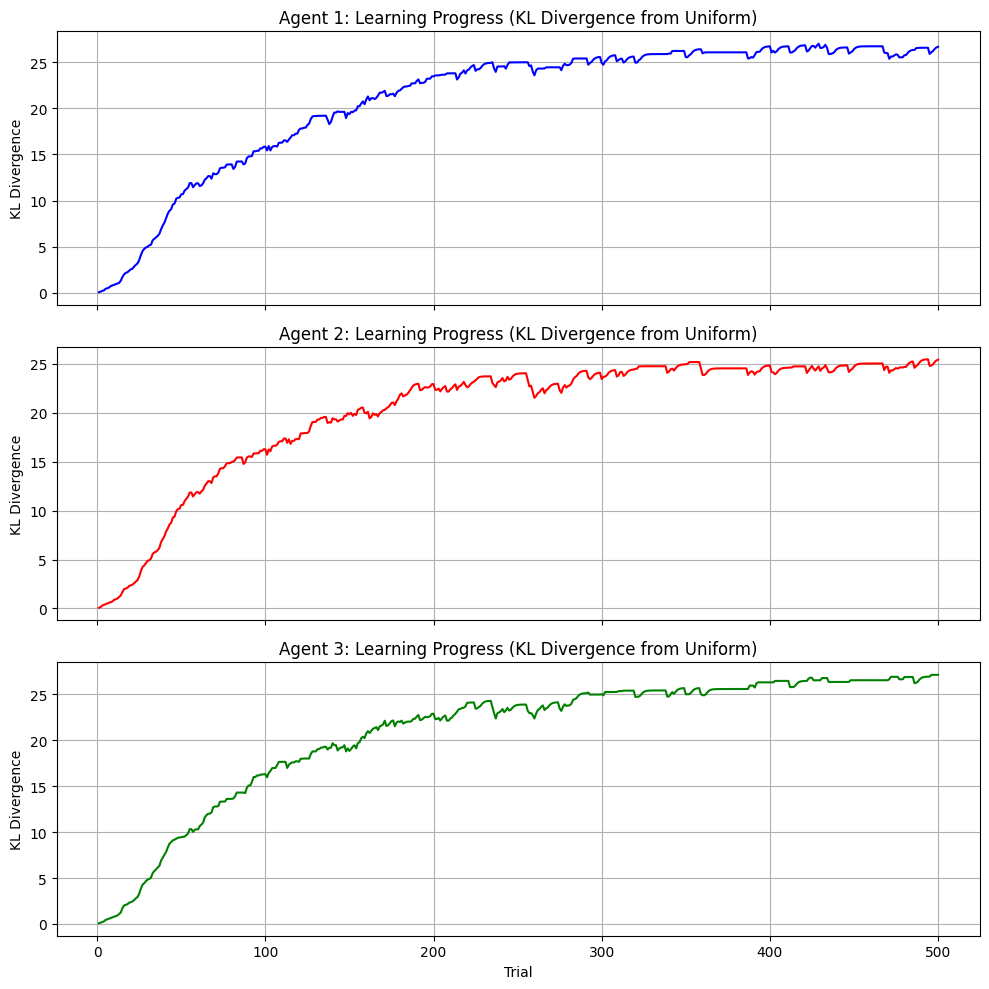

In [10]:
# --- Learning Progress via KL Divergence from Uniform ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
kl_colors = ['blue', 'red', 'green']
B_snap_all = [B_snap_1, B_snap_2, B_snap_3]

for i, B_snapshots in enumerate(B_snap_all):
    kl_history = []
    for B in B_snapshots:
        kl = 0
        for old_s in range(8):         # 8 hidden states
            for a in range(2):         # 2 actions
                current_dist = B[:, old_s, a]
                prior_dist = np.ones(8) / 8  # uniform prior
                kl += np.sum(rel_entr(current_dist, prior_dist))
        kl_history.append(kl)

    axes[i].plot(range(1, len(kl_history) + 1), kl_history, color=kl_colors[i])
    axes[i].set_title(f'Agent {i+1}: Learning Progress (KL Divergence from Uniform)')
    axes[i].set_ylabel('KL Divergence')
    axes[i].grid(True)

axes[-1].set_xlabel('Trial')
plt.tight_layout()
plt.show()


/var/folders/6x/9d46tdkd7wv0t20rrvptw4d00000gn/T/ipykernel_92024/2958328915.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


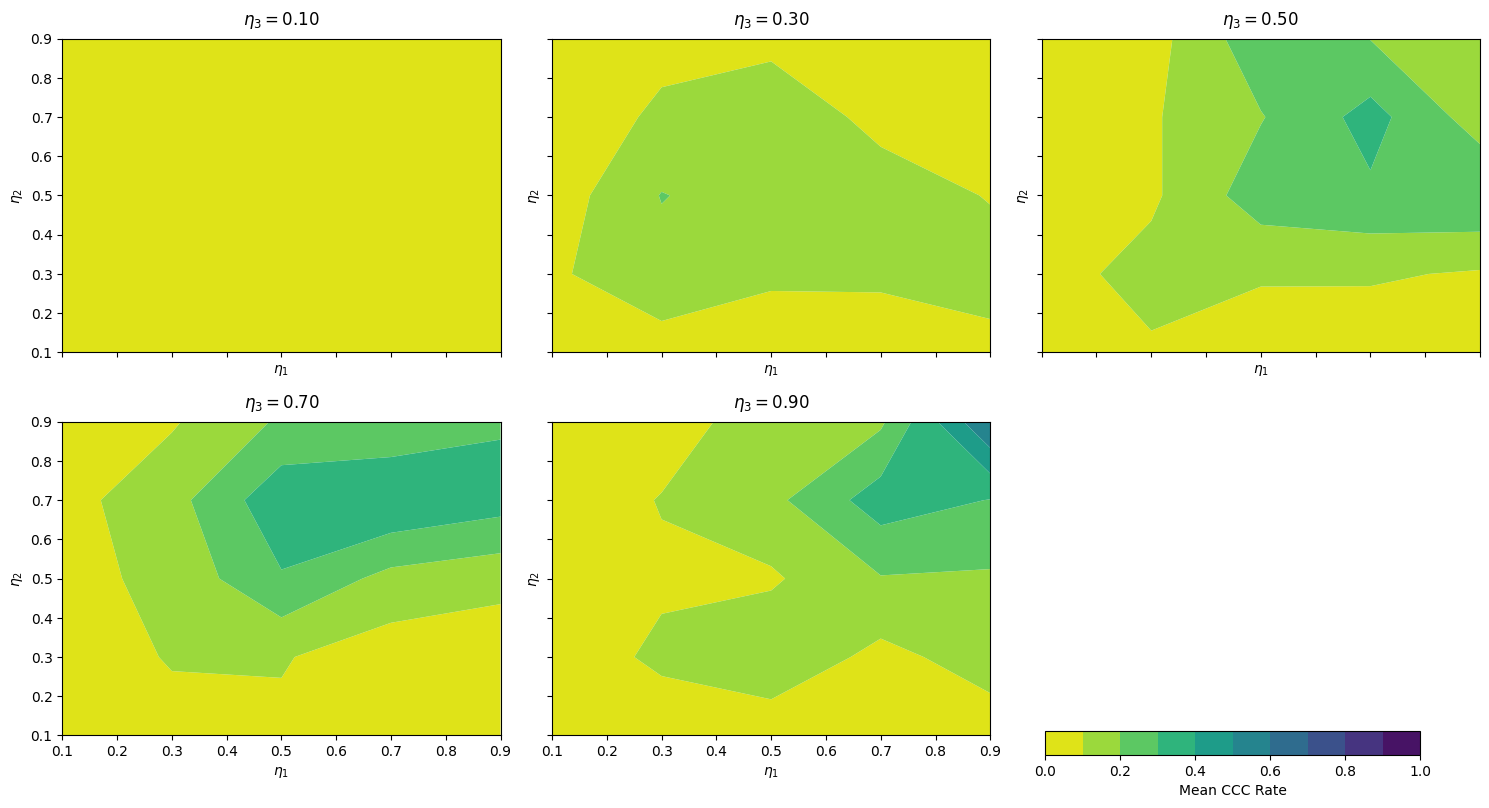

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

def run_simulation_3agent(eta1, eta2, eta3, gamma, N):
    C1 = np.array([3,   0.5, 0.5, 0.5, 4,   2.5, 2.5, 1])
    C2 = np.array([3,   0.5, 4,   2.5, 0.5, 0.5, 2.5, 1])
    C3 = np.array([3,   4,   0.5, 2.5, 0.5, 2.5, 0.5, 1])

    env      = IPDEnvironment3A()
    a1_agent = ActiveInferenceAgent("A1", C1, alpha=default_alpha1, eta=eta1, gamma=gamma)
    a2_agent = ActiveInferenceAgent("A2", C2, alpha=default_alpha2, eta=eta2, gamma=gamma)
    a3_agent = ActiveInferenceAgent("A3", C3, alpha=default_alpha3, eta=eta3, gamma=gamma)

    states = []
    old    = env.state

    for t in range(N):
        a1_agent.observe_and_infer_state(old)
        a2_agent.observe_and_infer_state(old)
        a3_agent.observe_and_infer_state(old)

        if t == 0:
            a1, a2, a3 = np.random.randint(2), np.random.randint(2), np.random.randint(2)
        else:
            a1, a2, a3 = a1_agent.select_action(), a2_agent.select_action(), a3_agent.select_action()

        new = env.step(a1, a2, a3)
        a1_agent.update_transition_model(old, a1, new)
        a2_agent.update_transition_model(old, a2, new)
        a3_agent.update_transition_model(old, a3, new)

        states.append(new)
        old = new

    # return fraction of CCC (state 0)
    return np.mean(np.array(states) == 0)


def average_cooperation_3agent(eta1, eta2, eta3, gamma, runs, N):
    rates = [run_simulation_3agent(eta1, eta2, eta3, gamma, N)
             for _ in range(runs)]
    return np.mean(rates), rates


# Parameters
np.random.seed(42)
etas      = np.round(np.arange(0.1, 1.0, 0.2), 2)
gamma_val = default_gamma
R, N      = default_runs, default_N
thr       = 0.60

# Allocate storage
n         = len(etas)
mean_coop = np.zeros((n, n, n))
pvals     = np.ones((n, n, n))

# Run sims + t-tests
for k, e3 in enumerate(etas):
    for i, e1 in enumerate(etas):
        for j, e2 in enumerate(etas):
            m, samples        = average_cooperation_3agent(e1, e2, e3, gamma_val, R, N)
            mean_coop[i, j, k] = m
            t_stat, p_two     = ttest_1samp(samples, thr, nan_policy='omit')
            pvals[i, j, k]    = (p_two/2) if t_stat>0 else (1 - p_two/2)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes      = axes.flat
levels    = np.linspace(0, 1, 11)
X, Y      = np.meshgrid(etas, etas)
slices    = [0, 1, 2, 3, 4]  # five η₃ slices

for ax, k in zip(axes[:5], slices):
    Z  = mean_coop[:, :, k].T
    PV = pvals[:, :, k].T

    cf = ax.contourf(
        X, Y, Z,
        levels=levels,
        cmap='viridis_r',
        vmin=0, vmax=1,
        antialiased=True
    )

    # mark significant cells
    sy, sx = np.where(PV < 0.05)
    ax.scatter(
        etas[sx], etas[sy],
        marker='*', color='white', s=80, edgecolor='k'
    )

    ax.set_title(f"$\\eta_3 = {etas[k]:.2f}$", pad=10)
    ax.set_xlabel("$\\eta_1$")
    ax.set_ylabel("$\\eta_2$")

# hide the unused axis
axes[5].axis('off')


# … after drawing the 5 filled contours and hiding axes[5] …

# Make room on the bottom‐right for our horizontal colorbar
cax = fig.add_axes([0.70,   # left position (70% of figure width)
                    0.05,   # bottom position (5% of figure height)
                    0.25,   # width (25% of figure width)
                    0.03])  # height (3% of figure height)

# Draw the horizontal colorbar into that new axes
cb = fig.colorbar(cf, cax=cax, orientation='horizontal')
cb.set_label("Mean CCC Rate")

plt.tight_layout()
plt.show()
